# Clustering Analysis — World Development Dataset

## Data Mining Project Notebook

This notebook applies clustering methods to discover groups of countries with similar development patterns.

The style is intentionally similar to the class clustering assignment:

1. Load and prepare the data
2. Average all years into one row per country
3. Scale the numeric indicators
4. Use the **Elbow Method correctly** to select the number of K-Means clusters
5. Apply K-Means, Hierarchical Clustering, and DBSCAN
6. Compare the methods
7. Save the final clustered dataset

> Important: We do **not** use `year` for clustering because each country has many yearly records.  
> For clustering, each country should appear once using its average indicator values from 2010–2023.

## Imports

In [29]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42

# Create output folders
CHART_DIR = "../charts/clustering"
DATA_DIR = "../after_processing_dataset"
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


## Helper Function: Show and Save Charts

Every chart in this notebook is displayed in the cell and also saved to the `charts/clustering/` folder.

In [30]:
def save_chart(filename):
    """Save the current matplotlib figure and display it."""
    path = os.path.join(CHART_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved chart to: {path}")

---
# Part 1: Load Dataset

The notebook first tries the relative path that should work when the notebook is inside your project folder.
If that fails, it tries the absolute Mac path you provided.

In [31]:
possible_paths = [
    "../sample_datasets/world_panel_2010_2023.csv",
    "sample_datasets/world_panel_2010_2023.csv",
    "/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv"
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Dataset not found. Make sure world_panel_2010_2023.csv exists in sample_datasets/.")

df = pd.read_csv(data_path)
print("Dataset loaded from:", data_path)
print("Shape:", df.shape)
df.head()

Dataset loaded from: ../sample_datasets/world_panel_2010_2023.csv
Shape: (336, 22)


,country,code,region,year,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,2010,4228.1,0.4909,72.14,87.32,25.38,1.185,...,5.521,8.038,50.25,0.1510,53.42,14.99,39.19,67.62,553.0,260960120
1,Algeria,DZA,Africa,2011,4374.9,0.4849,72.37,86.10,34.32,1.176,...,5.321,7.755,52.43,0.2402,53.22,10.16,37.60,68.63,551.4,268501465
2,Algeria,DZA,Africa,2012,4500.8,0.4914,72.45,87.41,33.08,1.145,...,5.152,7.301,44.42,-0.0675,52.50,14.07,43.97,67.39,554.0,276758265
3,Algeria,DZA,Africa,2013,4649.6,0.4930,72.46,87.03,31.79,1.453,...,5.712,7.988,50.39,0.0478,54.45,11.86,43.34,68.68,522.7,285130821
4,Algeria,DZA,Africa,2014,4744.8,0.4983,72.98,89.22,34.49,1.174,...,5.411,8.000,46.90,0.1721,53.59,11.30,43.23,67.58,524.3,292485149


In [32]:
print("Columns:")
print(df.columns.tolist())

print("\nYear range:", df["year"].min(), "to", df["year"].max())
print("Number of countries:", df["country"].nunique())
print("Number of regions:", df["region"].nunique())

Columns:
['country', 'code', 'region', 'year', 'gdp_per_capita', 'hdi', 'life_expectancy', 'literacy_rate', 'internet_usage_pct', 'co2_per_capita', 'fertility_rate', 'infant_mortality', 'education_spending_pct', 'health_spending_pct', 'gini_index', 'political_stability', 'urbanization_rate', 'unemployment_rate', 'renewable_energy_pct', 'access_to_water_pct', 'maternal_mortality', 'population']

Year range: 2010 to 2023
Number of countries: 24
Number of regions: 5


In [33]:
# Check missing values and duplicates
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Series([], dtype: int64)

Duplicate rows: 0


## Preprocessing Idea

For clustering, we need one vector per country.  
The original dataset has multiple years for the same country, so we average the numeric indicators across years.

Example:

- USA 2010
- USA 2011
- USA 2012
- ...

becomes one row:

- USA average development profile

We exclude `year` from the clustering features.

In [34]:
# Select numeric columns but remove year because clustering should not depend on time
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != "year"]

print("Features used for clustering:")
print(feature_cols)
print("\nNumber of features:", len(feature_cols))

Features used for clustering:
['gdp_per_capita', 'hdi', 'life_expectancy', 'literacy_rate', 'internet_usage_pct', 'co2_per_capita', 'fertility_rate', 'infant_mortality', 'education_spending_pct', 'health_spending_pct', 'gini_index', 'political_stability', 'urbanization_rate', 'unemployment_rate', 'renewable_energy_pct', 'access_to_water_pct', 'maternal_mortality', 'population']

Number of features: 18


In [35]:
# Average all numeric indicators by country
country_df = (
    df.groupby(["country", "code", "region"], as_index=False)[feature_cols]
      .mean()
)

print("Original yearly dataset shape:", df.shape)
print("Country-level averaged dataset shape:", country_df.shape)
country_df.head()

Original yearly dataset shape: (336, 22)
Country-level averaged dataset shape: (24, 21)


,country,code,region,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,5143.785714,0.503800,72.781429,89.336429,45.450714,1.327429,4.192143,...,5.555786,7.769714,48.761429,0.157707,55.727857,12.152857,44.980000,70.582143,503.871429,3.155758e+08
1,Australia,AUS,Oceania,61492.571429,0.888693,83.382143,99.456429,65.528571,18.231357,1.849071,...,7.693786,12.459571,41.161429,1.828164,85.795714,7.411429,28.705000,97.077143,99.864286,1.102839e+08
2,Brazil,BRA,Americas,8740.550000,0.571457,74.648571,91.860000,47.589286,2.540500,3.757143,...,5.953643,9.007286,47.495714,0.464914,61.052857,11.235714,41.770000,75.321429,436.085714,2.434108e+08
3,China,CHN,Asia,34129.571429,0.689100,78.213571,95.208571,54.845714,3.871000,3.109143,...,6.693429,10.105571,45.721429,1.022550,70.200714,9.788571,36.072857,83.485000,309.814286,1.602121e+08
4,Egypt,EGY,Africa,5080.714286,0.509893,73.010714,89.993571,45.650714,1.384643,4.149714,...,5.494357,7.891357,48.292143,0.134586,56.335000,12.375000,43.107143,71.165714,497.064286,1.786839e+08


In [36]:
# Impute missing values and scale features
X_raw = country_df[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("Scaled feature matrix shape:", X_scaled_df.shape)
X_scaled_df.head()

Scaled feature matrix shape: (24, 18)


,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,infant_mortality,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,-0.680392,-0.769929,-0.761701,-0.782048,-0.728753,-0.734670,0.778557,0.796493,-0.699877,-0.811516,0.734854,-0.794367,-0.783603,0.782629,0.851811,-0.799657,0.768045,1.712367
1,0.824649,1.271747,1.273647,1.337811,1.353579,1.282712,-1.293700,-1.276896,1.177521,1.259699,-1.485359,1.194886,1.271431,-1.192503,-1.293823,1.362502,-1.294051,-0.636944
2,-0.584324,-0.411040,-0.403208,-0.253430,-0.506955,-0.589898,0.393835,0.402543,-0.350515,-0.264959,0.365097,-0.428531,-0.419658,0.400576,0.428617,-0.412901,0.422060,0.886528
3,0.093800,0.213001,0.281276,0.448003,0.245630,-0.431110,-0.179269,-0.219116,0.299098,0.220085,-0.153231,0.235525,0.205566,-0.202259,-0.322473,0.253298,-0.222443,-0.065578
4,-0.682076,-0.737609,-0.717678,-0.644395,-0.708010,-0.727842,0.741033,0.730592,-0.753818,-0.757794,0.597760,-0.821901,-0.742107,0.875166,0.604900,-0.752033,0.733301,0.145809


---
# Part 2: K-Means Clustering

K-Means needs the number of clusters `k` before training.  
To choose `k`, we use two simple checks:

1. **Elbow Method** using inertia
2. **Silhouette Score** using different values of `k`

The elbow method finds where the inertia curve starts to bend.  
In this notebook, we also calculate the elbow point using the **maximum distance from the straight line** between the first and last points. This makes the decision less random.

In [37]:
# Elbow Method
K_range = range(1, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

elbow_df = pd.DataFrame({"k": list(K_range), "inertia": inertias})
elbow_df

,k,inertia
0,1,432.000000
1,2,99.827905
2,3,62.378310
3,4,46.412599
4,5,32.779348
5,6,24.453090
6,7,19.537270
7,8,15.760144
8,9,13.312185
9,10,10.973524


In [38]:
# Automatic elbow detection using maximum distance to a line
# This is a simple and explainable version of the elbow/knee method.
ks = np.array(list(K_range))
inertia_values = np.array(inertias)

# Line from first point to last point
point_first = np.array([ks[0], inertia_values[0]])
point_last = np.array([ks[-1], inertia_values[-1]])
line_vector = point_last - point_first

# Distance of each point from the line
points = np.column_stack([ks, inertia_values])
distances = np.abs(np.cross(line_vector, points - point_first) / np.linalg.norm(line_vector))
auto_elbow_k = int(ks[np.argmax(distances)])

elbow_df["distance_from_line"] = distances
print("Automatic elbow k:", auto_elbow_k)
elbow_df

Automatic elbow k: 2


,k,inertia,distance_from_line
0,1,432.000000,0.000000
1,2,99.827905,6.099226
2,3,62.378310,5.899807
3,4,46.412599,5.241245
4,5,32.779348,4.532836
5,6,24.453090,3.711009
6,7,19.537270,2.816295
7,8,15.760144,1.897246
8,9,13.312185,0.949791
9,10,10.973524,0.000000


### How to Read the Elbow Chart

The best `k` is usually where the curve changes from steep improvement to slower improvement.  
For this dataset, the elbow is expected to be around **4 or 5**.

To make the final choice more defensible, we also check silhouette scores for `k = 2` to `k = 8`.

In [40]:
# Silhouette and other validation scores for k = 2 to 8
k_eval = range(2, 9)
kmeans_scores = []

for k in k_eval:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    kmeans_scores.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels)
    })

kmeans_scores_df = pd.DataFrame(kmeans_scores)
kmeans_scores_df

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,99.827905,0.626642,73.203841,0.494270
1,3,62.378310,0.501047,62.217584,0.665045
2,4,46.412599,0.328455,55.385450,0.945855
3,5,32.779348,0.370789,57.850391,0.791540
4,6,24.453090,0.392753,59.999324,0.747261
5,7,19.537270,0.373175,59.816158,0.715097
6,8,15.760144,0.341057,60.367809,0.718445


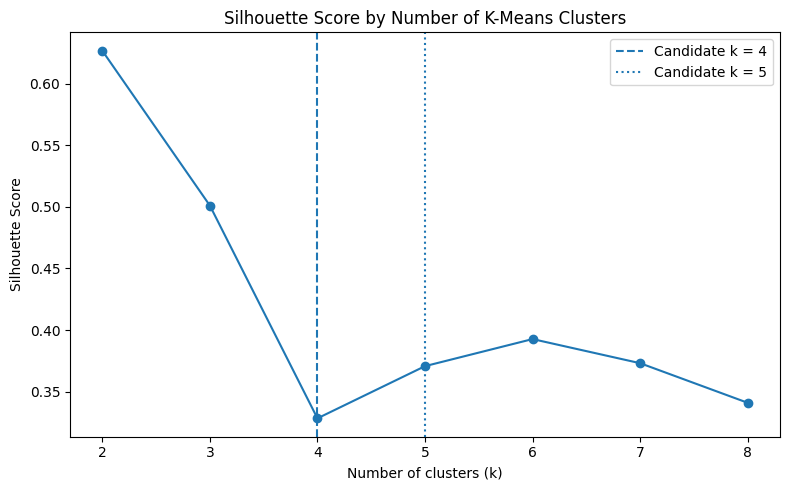

Saved chart to: ../charts/clustering/02_kmeans_silhouette_scores.png


In [41]:
plt.figure(figsize=(8, 5))
plt.plot(kmeans_scores_df["k"], kmeans_scores_df["silhouette"], marker="o")
plt.axvline(4, linestyle="--", label="Candidate k = 4")
plt.axvline(5, linestyle=":", label="Candidate k = 5")
plt.title("Silhouette Score by Number of K-Means Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_eval))
plt.legend()
save_chart("02_kmeans_silhouette_scores.png")

## Final K-Means Choice

Use this rule:

- If the elbow is very clear at 4, use `k = 4`.
- If the elbow is between 4 and 5 and silhouette does not strongly reject 5, use `k = 5`.

In [42]:
# You can change this to 5 if you want a more detailed segmentation.
FINAL_K = 4

kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans.fit_predict(X_scaled)

country_df["kmeans_cluster"] = kmeans_labels

print("Final K-Means k:", FINAL_K)
print("Cluster counts:")
print(country_df["kmeans_cluster"].value_counts().sort_index())

Final K-Means k: 4
Cluster counts:
kmeans_cluster
0    8
1    6
2    6
3    4
Name: count, dtype: int64


### PCA Visualization for K-Means

Because the data has many indicators, we use PCA only for visualization.  
The clustering itself was performed on all scaled indicators, not only two PCA columns.

In [43]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

country_df["PC1"] = X_pca[:, 0]
country_df["PC2"] = X_pca[:, 1]

print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance by PC1 and PC2:
[0.93238743 0.04917329]
Total explained variance: 0.981560720024066


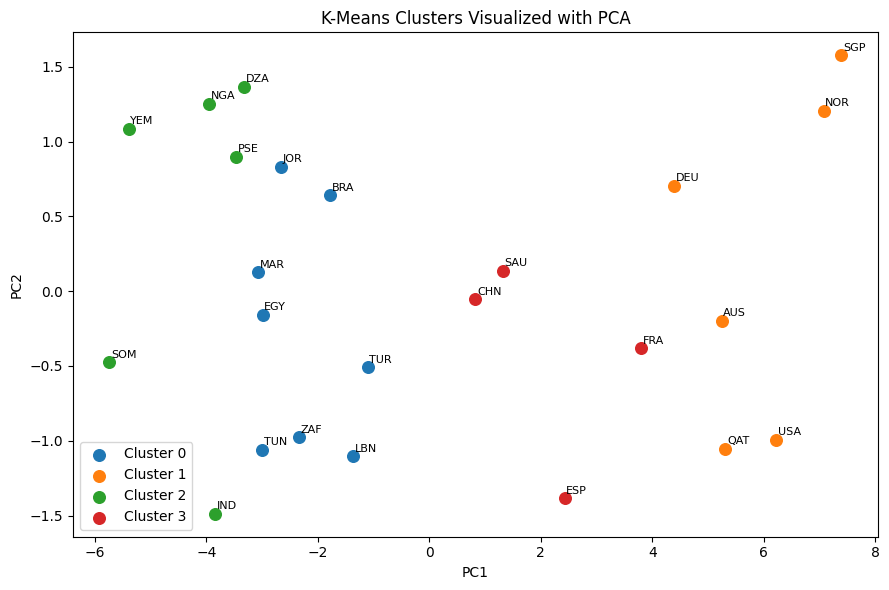

Saved chart to: ../charts/clustering/03_kmeans_pca_clusters.png


In [44]:
plt.figure(figsize=(9, 6))
for cluster in sorted(country_df["kmeans_cluster"].unique()):
    mask = country_df["kmeans_cluster"] == cluster
    plt.scatter(country_df.loc[mask, "PC1"], country_df.loc[mask, "PC2"], label=f"Cluster {cluster}", s=70)

# Label countries because the dataset is small
for _, row in country_df.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["code"], fontsize=8)

plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
save_chart("03_kmeans_pca_clusters.png")

### Cluster Profiles

This table shows the average original indicator values for each cluster.  
Use it to give names to the clusters, such as:

- High development countries
- Emerging economies
- Lower development countries
- Resource-dependent or unusual development profile

In [45]:
cluster_profiles = country_df.groupby("kmeans_cluster")[feature_cols].mean().round(2)
cluster_profiles

,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,infant_mortality,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
kmeans_cluster,,,,,,,,,,,,,,,,,,
0,7978.54,0.54,73.96,90.76,47.48,2.01,3.95,55.09,5.74,8.36,48.00,0.33,58.85,11.60,42.63,73.31,465.00,1.633464e+08
1,83619.81,0.92,84.12,99.43,66.11,20.71,1.67,11.53,7.99,12.89,41.44,2.01,88.41,6.77,27.52,97.94,69.53,1.306980e+08
2,2228.03,0.45,71.11,87.55,41.97,0.79,4.48,65.39,5.15,7.24,49.90,-0.03,52.04,12.76,46.56,67.57,556.66,2.367225e+08
3,38977.22,0.75,79.73,96.42,57.79,8.65,2.74,31.67,6.93,10.73,44.48,1.32,74.77,9.15,34.73,87.39,251.09,1.178316e+08


In [46]:
# Save K-Means results
kmeans_output_path = os.path.join(DATA_DIR, "country_kmeans_clusters.csv")
country_df.to_csv(kmeans_output_path, index=False)
print("Saved K-Means clustered dataset to:", kmeans_output_path)

Saved K-Means clustered dataset to: ../after_processing_dataset/country_kmeans_clusters.csv


---
# Part 3: Hierarchical Clustering

Hierarchical clustering does not start with random centroids.  
It builds a tree of clusters using distances between countries.

We use a dendrogram to decide where to cut the tree.  
For consistency with K-Means, we test `k = 4` and `k = 5` and compare silhouette scores.

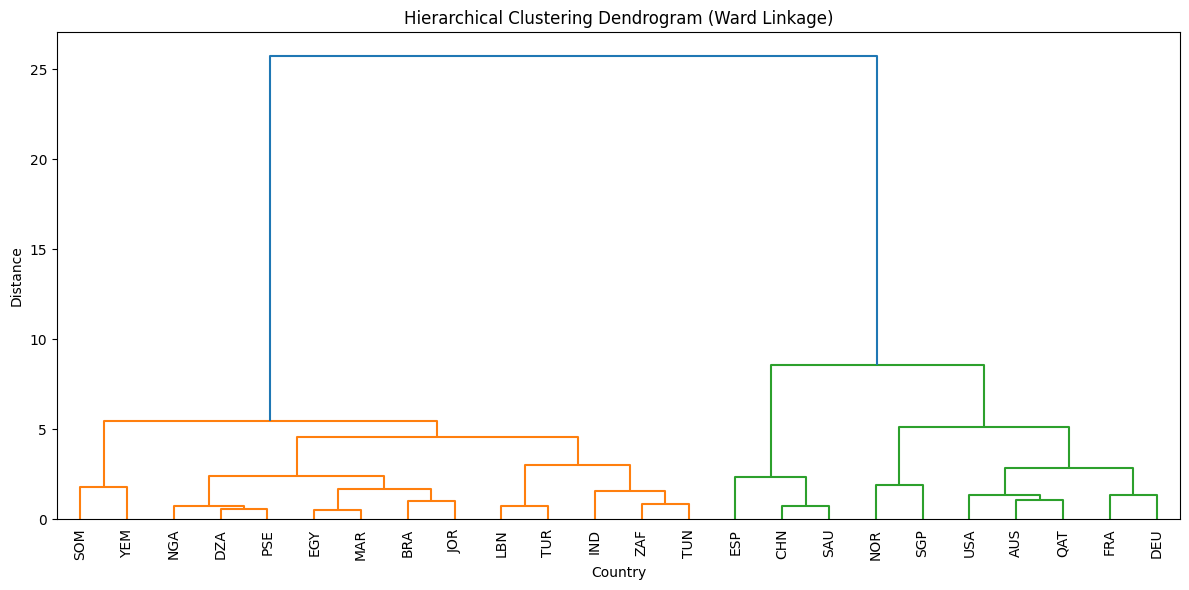

Saved chart to: ../charts/clustering/04_hierarchical_dendrogram.png


In [47]:
# Dendrogram using Ward linkage
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=country_df["code"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Country")
plt.ylabel("Distance")
save_chart("04_hierarchical_dendrogram.png")

In [48]:
# Compare k=4 and k=5 for Hierarchical clustering
hier_results = []

for k in [4, 5]:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    hier_results.append({
        "method": "Hierarchical Ward",
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels)
    })

hier_results_df = pd.DataFrame(hier_results)
hier_results_df

,method,k,silhouette,calinski_harabasz,davies_bouldin
0,Hierarchical Ward,4,0.398452,53.222101,0.676670
1,Hierarchical Ward,5,0.397095,53.889011,0.674642


In [49]:
# Select best hierarchical k by silhouette score
BEST_HIER_K = int(hier_results_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

hier_model = AgglomerativeClustering(n_clusters=BEST_HIER_K, linkage="ward")
hier_labels = hier_model.fit_predict(X_scaled)
country_df["hierarchical_cluster"] = hier_labels

print("Best Hierarchical k:", BEST_HIER_K)
print("Cluster counts:")
print(country_df["hierarchical_cluster"].value_counts().sort_index())

Best Hierarchical k: 4
Cluster counts:
hierarchical_cluster
0     7
1    12
2     3
3     2
Name: count, dtype: int64


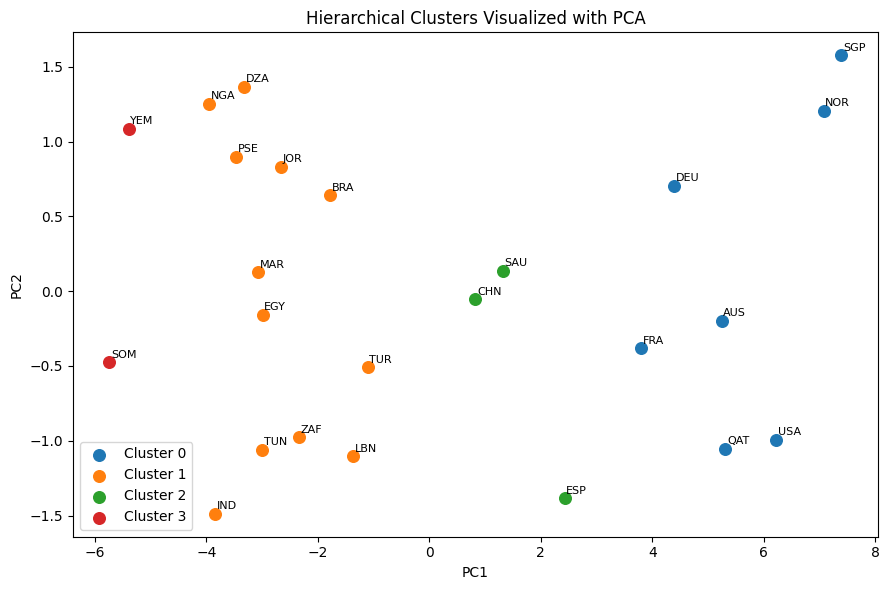

Saved chart to: ../charts/clustering/05_hierarchical_pca_clusters.png


In [50]:
plt.figure(figsize=(9, 6))
for cluster in sorted(country_df["hierarchical_cluster"].unique()):
    mask = country_df["hierarchical_cluster"] == cluster
    plt.scatter(country_df.loc[mask, "PC1"], country_df.loc[mask, "PC2"], label=f"Cluster {cluster}", s=70)

for _, row in country_df.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["code"], fontsize=8)

plt.title("Hierarchical Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
save_chart("05_hierarchical_pca_clusters.png")

---
# Part 4: DBSCAN

DBSCAN detects dense groups and marks unusual points as noise.  
Unlike K-Means, it does not require `k`, but it needs:

- `eps`: neighborhood distance
- `min_samples`: minimum points needed to form a dense area

We use the k-distance plot to choose a reasonable `eps`.  
The elbow in this plot is a good starting point for `eps`.

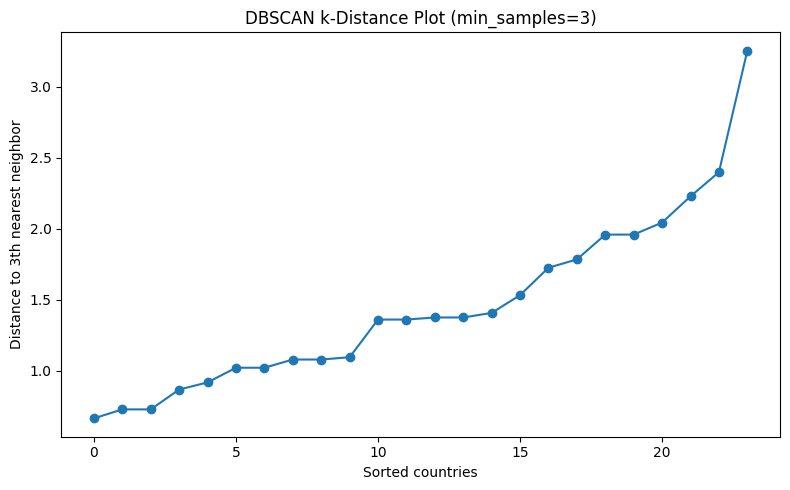

Saved chart to: ../charts/clustering/06_dbscan_k_distance.png


In [51]:
# k-distance plot for DBSCAN
min_samples = 3
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, marker="o")
plt.title(f"DBSCAN k-Distance Plot (min_samples={min_samples})")
plt.xlabel("Sorted countries")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
save_chart("06_dbscan_k_distance.png")

In [52]:
# Simple DBSCAN parameter sweep
# Because the dataset is small, we test a small set of values and choose the highest silhouette score.
eps_values = np.arange(1.0, 4.1, 0.25)
min_samples_values = [2, 3, 4]

dbscan_results = []

for eps in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)
        
        if n_clusters >= 2 and noise_ratio < 0.60:
            sil = silhouette_score(X_scaled, labels)
        else:
            sil = np.nan
        
        dbscan_results.append({
            "eps": round(eps, 2),
            "min_samples": ms,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil
        })

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df.sort_values("silhouette", ascending=False).head(10)

,eps,min_samples,n_clusters,noise_ratio,silhouette
12,2.00,2,3,0.000000,0.525031
13,2.00,3,2,0.083333,0.525031
14,2.00,4,2,0.208333,0.423762
10,1.75,3,2,0.250000,0.400151
11,1.75,4,2,0.250000,0.400151
15,2.25,2,2,0.000000,0.366758
7,1.50,3,2,0.291667,0.346379
9,1.75,2,3,0.166667,0.338381
8,1.50,4,2,0.333333,0.304575
6,1.50,2,3,0.208333,0.300916


In [53]:
# Select DBSCAN parameters
valid_dbscan = dbscan_results_df.dropna(subset=["silhouette"]).copy()

if len(valid_dbscan) == 0:
    print("No valid DBSCAN solution found. DBSCAN may not be suitable for this dataset.")
    dbscan_labels = np.full(len(country_df), -1)
    best_eps = None
    best_min_samples = None
else:
    best_row = valid_dbscan.sort_values("silhouette", ascending=False).iloc[0]
    best_eps = float(best_row["eps"])
    best_min_samples = int(best_row["min_samples"])
    
    dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    print("Best DBSCAN eps:", best_eps)
    print("Best DBSCAN min_samples:", best_min_samples)
    print("Number of clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
    print("Noise countries:", np.sum(dbscan_labels == -1))

country_df["dbscan_cluster"] = dbscan_labels
country_df["dbscan_cluster"].value_counts().sort_index()

Best DBSCAN eps: 2.0
Best DBSCAN min_samples: 2
Number of clusters: 3
Noise countries: 0


dbscan_cluster
0    14
1     8
2     2
Name: count, dtype: int64

---
# Part 5: Final Method Comparison

For the final project, K-Means is usually the easiest clustering method to explain because:

- the elbow method gives a clear way to select `k`
- clusters are easy to visualize
- cluster profiles are easy to interpret

Hierarchical clustering is useful as confirmation.  
DBSCAN is useful for detecting noise/outlier countries, but it may not always create balanced clusters.

In [54]:
def evaluate_labels(method_name, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)
    
    if n_clusters < 2:
        return {
            "method": method_name,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan
        }
    
    return {
        "method": method_name,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels)
    }

comparison_df = pd.DataFrame([
    evaluate_labels(f"K-Means k={FINAL_K}", kmeans_labels),
    evaluate_labels(f"Hierarchical Ward k={BEST_HIER_K}", hier_labels),
    evaluate_labels("DBSCAN", dbscan_labels)
])

comparison_df

,method,n_clusters,noise_ratio,silhouette,calinski_harabasz,davies_bouldin
0,K-Means k=4,4,0.0,0.328455,55.385450,0.945855
1,Hierarchical Ward k=4,4,0.0,0.398452,53.222101,0.676670
2,DBSCAN,3,0.0,0.525031,51.605594,0.620748


In [55]:
comparison_path = os.path.join(DATA_DIR, "clustering_method_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
print("Saved method comparison to:", comparison_path)

Saved method comparison to: ../after_processing_dataset/clustering_method_comparison.csv


## Recommended Final Choice

For the project report/demo, I recommend using:

> **K-Means with k = 4 or k = 5**, selected using the elbow method and checked using silhouette score.

A good explanation would be:

> “The elbow curve shows a strong drop in inertia until around k = 4 or k = 5. After that, the improvement becomes smaller. Therefore, k = 4/5 was selected because it balances interpretability and cluster quality.”

Use `k = 4` if you want simpler cluster names.  
Use `k = 5` if the groups look more meaningful in the PCA scatter plot.

In [56]:
# Save final dataset with all clustering labels
final_output_path = os.path.join(DATA_DIR, "country_clustering_final_simple.csv")
country_df.to_csv(final_output_path, index=False)

print("Final clustering dataset saved to:", final_output_path)
country_df[["country", "code", "region", "kmeans_cluster", "hierarchical_cluster", "dbscan_cluster", "PC1", "PC2"]].head()

Final clustering dataset saved to: ../after_processing_dataset/country_clustering_final_simple.csv


,country,code,region,kmeans_cluster,hierarchical_cluster,dbscan_cluster,PC1,PC2
0,Algeria,DZA,Africa,2,1,0,-3.320247,1.368234
1,Australia,AUS,Oceania,1,0,1,5.246327,-0.197802
2,Brazil,BRA,Americas,0,1,0,-1.779923,0.640402
3,China,CHN,Asia,3,2,1,0.824856,-0.054939
4,Egypt,EGY,Africa,0,1,0,-2.990642,-0.157963


# Conclusion

This notebook used three clustering approaches:

1. **K-Means** — best for the main project explanation because the elbow method supports choosing the number of clusters.
2. **Hierarchical Clustering** — useful for dendrogram-based validation.
3. **DBSCAN** — useful for finding dense groups and possible outlier/noise countries.
